In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [3]:
# Load the fine-tuned model
gpt2_lm = keras.models.load_model("/kaggle/input/dialog_v3/keras/default/1/fine_tuned_gpt2_dialog_v2.keras", compile=False)

# (Re)compile with same or new optimizer
gpt2_lm.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-5))

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 394 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Load dataset
df = pd.read_feather("/kaggle/input/diagnoise-me/diagnose_en_dataset.feather").iloc[45000:60000]
print(df[["Patient", "Doctor"]].head())

# Combine question and answer into dialogue format
df["text"] = df.apply(lambda row: f"Patient: {row['Patient']}\nDoctor: {row['Doctor']}", axis=1)

                                                 Patient  \
45000  I m a 29 year old female. I have this rash on ...   
45001  Hi,I have had problems with eczema since I was...   
45002  I have a very itchy dry rash that was treated ...   
45003  Red rashes & itching worsen in the mostly in t...   
45004  I think I have singles Have a rash on my back ...   

                                                  Doctor  
45000  Hello and Welcome to ‘Ask A Doctor’ service. I...  
45001  Hello and Welcome to ‘Ask A Doctor’ service. I...  
45002  Hello and Welcome to ‘Ask A Doctor’ service. I...  
45003  Hello and Welcome to ‘Ask A Doctor’ service. I...  
45004  Hello and Welcome to ‘Ask A Doctor’ service. I...  


In [5]:
# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")

batch_size = 2
train_ds = tf.data.Dataset.from_tensor_slices(train_df["text"].values)
train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(batch_size)

val_ds = tf.data.Dataset.from_tensor_slices(val_df["text"].values)
val_ds = val_ds.shuffle(buffer_size=len(val_df)).batch(batch_size)

Train size: (12000, 5)
Validation size: (3000, 5)


In [6]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4220s 692ms/step - loss: 0.6965 - sparse_categorical_accuracy: 0.4280 - val_loss: 0.6383 - val_sparse_categorical_accuracy: 0.4657
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4141s 690ms/step - loss: 0.6158 - sparse_categorical_accuracy: 0.4728 - val_loss: 0.6254 - val_sparse_categorical_accuracy: 0.4751
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4138s 690ms/step - loss: 0.5722 - sparse_categorical_accuracy: 0.4929 - val_loss: 0.6197 - val_sparse_categorical_accuracy: 0.4786
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4137s 689ms/step - loss: 0.5465 - sparse_categorical_accuracy: 0.5082 - val_loss: 0.6218 - val_sparse_categorical_accuracy: 0.4805
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4139s 690ms/step - loss: 0.5210 - sparse_categorical_accuracy: 0.5225 - val_loss: 0.6239 - val_sparse_categorical_accuracy: 0.4817


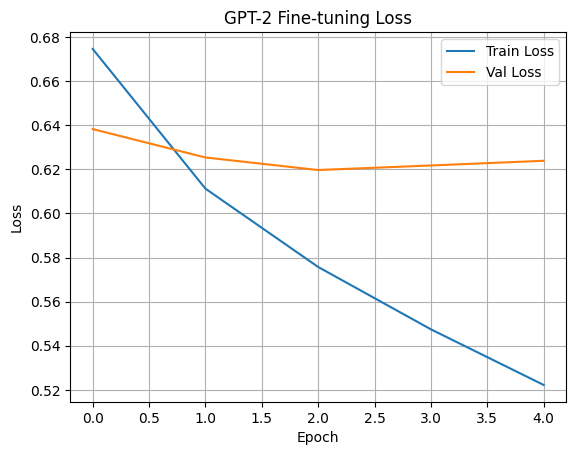

In [7]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_dialog_v4.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()

In [8]:
# Create a list to hold test results
results = []

# Generate and collect answers for 10 random questions
sample_df = df.sample(10, random_state=42)[["Patient", "Doctor"]]

for i, row in sample_df.iterrows():
    question = row["Patient"]
    true_answer = row["Doctor"]
    prompt = f"Patient: {question}\nDoctor:"
    
    # Generate model response
    generated = gpt2_lm.generate(prompt, max_length=100)
    
    # Save to results
    results.append({
        "question": question,
        "true_answer": true_answer,
        "generated_answer": generated
    })

# Save results to a DataFrame and then to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/test_results.csv", index=False)
print("✅ Saved test results to /kaggle/working/test_results.csv")

✅ Saved test results to /kaggle/working/test_results.csv
